In [ ]:
!uname -a       # OS and kernel version
!lscpu          # CPU details
!free -h        # RAM usage


In [20]:
!pip install networkx


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
# Use Black and isort to have a better format of the code\n",
# # run Black and isort on the entire file\n",
!pip install nbqa black isort

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [nbqa]6/9 [black]

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
# Essential Libraries
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn - Model Selection & Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.utils import shuffle

# Scikit-Learn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Scikit-Learn - Metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer,  precision_score,  recall_score, f1_score
from collections import Counter, defaultdict

# Initialize JavaScript for SHAP visualizations
shap.initjs()

In [2]:
# ! /usr/bin/python3 -m pip install git+https://github.com/vectorsss/shapG.git@force-plot-example
# !git clone https://github.com/vectorsss/strategy_inputs.git


In [3]:
# import os
# import sys

# # Point to the 'paper' folder
# strategy_path = '/home/fatemeh.hassanvand/AI-in-Metagenomics/strategy_inputs/paper'

# if strategy_path not in sys.path:
#     sys.path.insert(0, strategy_path)

# # Now this import will find the file we just created above
# from explainers.sampler import SamplerExplainer
# print(SamplerExplainer)

<class 'explainers.sampler.SamplerExplainer'>


In [22]:
# %%writefile /home/fatemeh.hassanvand/AI-in-Metagenomics/strategy_inputs/paper/explainers/sampler.py
# import numpy as np
# from tqdm import tqdm

# class SamplerExplainer:
#     def __init__(self, model, metric, collaborator_map, feature_names, mask_value, **kwargs):
#         self.model = model
#         self.metric = metric
#         self.collaborator_map = collaborator_map
#         self.feature_names = feature_names
#         self.mask_value = mask_value
#         self.max_collaborator_subset = kwargs.get('max_collaborator_subset', 5)

#     @staticmethod
#     def graph_to_collaborator_map(G):
#         cmap = {}
#         for node in G.nodes():
#             cmap[node] = list(G.neighbors(node))
#         return cmap

#     def explain(self, X, y, verbose=False):
#         """The actual ShapG calculation logic."""
#         if isinstance(X, np.ndarray):
#             X_df = X
#         else:
#             X_df = X.values
            
#         n_samples, n_features = X_df.shape
#         shap_values = {name: np.zeros(n_samples) for name in self.feature_names}
        
#         for i in tqdm(range(n_samples), disable=not verbose):
#             current_sample = X_df[i:i+1]
#             for feat_idx, feat_name in enumerate(self.feature_names):
#                 neighbors = self.collaborator_map.get(feat_name, [])
#                 marginal_contribution = self._estimate_marginal(current_sample, feat_idx, neighbors)
#                 shap_values[feat_name][i] = marginal_contribution
                
#         return shap_values

#     def _estimate_marginal(self, sample, feat_idx, neighbors):
#         X_with = np.copy(sample)
#         X_without = np.copy(sample)
#         X_without[0, feat_idx] = self.mask_value[feat_idx]
        
#         # Predict uses model directly
#         pred_with = self.metric(None, self.model.predict(X_with))
#         pred_without = self.metric(None, self.model.predict(X_without))
        
#         return (pred_with - pred_without).flatten()[0]

Overwriting /home/fatemeh.hassanvand/AI-in-Metagenomics/strategy_inputs/paper/explainers/sampler.py


In [2]:
### Necessary steps for using shapG ###
import shapG
import os
import sys

# 1. Global ShapG functions (These are part of the installed library)
shapley = shapG.shapG
shapGplot = shapG.plot
matrix_generator = shapG.matrix_generator
create_minimal_edge_graph = shapG.create_minimal_edge_graph
corr_generator = shapG.corr_generator
kl = shapG.kl
kl_mi_matrix = shapG.kl_mi_matrix
GraphBuilder = shapG.GraphBuilder

# 2. Tell Python where our CUSTOM SamplerExplainer is
strategy_path = '/home/fatemeh.hassanvand/AI-in-Metagenomics/strategy_inputs/paper'
if strategy_path not in sys.path:
    sys.path.insert(0, strategy_path)

# 3. Import it from the FILE, not the shapG library
from explainers.sampler import SamplerExplainer

# 4. Other libraries
import networkx as nx

print("Success! All modules loaded.")

Success! All modules loaded.


#### Borda Scoial Choice for Selecting top 3 common features of soil
For multi-class Soil Type, we use Borda method that is consensus-based ranking (Social Choice Theory). For binary tasks, we simply select the top 3 features per label

In [140]:
# Uncomment list1, list2, list3 of each classification category at the same time

# def borda_count_top3(*ranked_lists):
#     # Assume each list is a voter's ranked preferences (highest to lowest)
#     scores = defaultdict(int)
    
#     for voter_list in ranked_lists:
#         n = len(voter_list)
#         for rank, candidate in enumerate(voter_list):
#             # Top candidate gets n points, next gets n-1, ..., last gets 1
#             scores[candidate] += n - rank
    
#     # Print final aggregate scores
#     print("Final aggregate scores:")
#     for candidate, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
#         print(f"{candidate}: {score}")
    
#     # Sort candidates by total score, descending
#     sorted_candidates = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
#     # Return top 3 candidates
#     return [candidate for candidate, score in sorted_candidates[:3]]

# #### For Aviti, Soil, RandomForest #####
# # list1 = ['Roseimaritima',"Croceibacterium","SWB02","Fermentimonas","Hyphomicrobium",
# #     "Planctopirus","Azotobacter","Ideonella","Spirochaeta 2","Candidatus Solibacter",
# #     "Oligoflexus" ,"Ureibacillus"]
# # list2 = ["SWB02","Roseimaritima","Croceibacterium","Ideonella", "Hyphomicrobium",
# #     "Fermentimonas","Planctopirus","Azotobacter","Candidatus Solibacter","Spirochaeta 2",
# #     "Oligoflexus","Ureibacillus"]
# # list3 = ["Ideonella","Planctopirus","Azotobacter","Roseimaritima","SWB02","Croceibacterium",
# #             "Fermentimonas","Hyphomicrobium","Spirochaeta 2","Candidatus Solibacter","Oligoflexus"
# #              ,"Ureibacillus"]
# #### For Miseq, Soil, RandomForest #####
# # list1 = ["Croceibacterium","CL500-3","Dokdonella","SWB02","Gemmata","Arsenicitalea","Sphingorhabdus"
# #     ,"Bradyrhizobium","Pseudomonas","Shinella","Acidibacter"]
# # list2 = ["SWB02","Pseudomonas","Arsenicitalea","Croceibacterium","Dokdonella","CL500-3","Sphingorhabdus",
# #          "Gemmata","Shinella","Bradyrhizobium","Acidibacter"]
# # list3 = ["Sphingorhabdus","Shinella","SWB02","Pseudomonas","CL500-3","Acidibacter","Dokdonella",
# # "Croceibacterium","Gemmata","Arsenicitalea","Bradyrhizobium"]
# #### For Novaseq, Soil, RandomForest #####
# # list1 = ["Ketobacter","Candidatus Berkiella", "Plot4-2H12","Inhella", "Rhodopila","Runella","IS-44",
# # "Subgroup 10","Bauldia","Hydrogenispora","Dyadobacter","Brevifollis","Ruminofilibacter"]
# # list2 = ["Inhella","Plot4-2H12","Candidatus Berkiella","Ketobacter","Runella","Rhodopila","Bauldia",
# # "Subgroup 10","Dyadobacter","IS-44","Brevifollis","Hydrogenispora","Ruminofilibacter"]
# # list3 = ["Inhella","Plot4-2H12","Runella","Candidatus Berkiella","Rhodopila","Ketobacter","Bauldia",
# # "Subgroup 10","Dyadobacter","Brevifollis","IS-44","Ruminofilibacter","Hydrogenispora"]

# #### For Aviti, Soil, SVM #####
# # list1 = ["SWB02","Croceibacterium","Opitutus","Gemmata","Hyphomicrobium","Fimbriiglobus","Cellvibrio","YC-ZSS-LKJ147",
# # "BIyi10","Candidatus Solibacter","Agrobacterium","Streptomyces","Ideonella","Acidovorax","Polycyclovorans","Spirochaeta 2"]
# # list2 = ["SWB02", "Gemmata", "Polycyclovorans", "Croceibacterium", "Ideonella","Streptomyces","Opitutus", "Hyphomicrobium",
# # "Fimbriiglobus", "BIyi10", "Agrobacterium", "Candidatus Solibacter","Cellvibrio", "Spirochaeta 2","Acidovorax","YC-ZSS-LKJ147"]
# # list3 = ["SWB02", "Ideonella", "Opitutus", "Polycyclovorans","Gemmata", "Hyphomicrobium","YC-ZSS-LKJ147", "Streptomyces",
# # "Croceibacterium", "Agrobacterium", "Acidovorax", "Cellvibrio","BIyi10", "Candidatus Solibacter", "Fimbriiglobus", "Spirochaeta 2"]
# #### For Miseq, Soil, SVM #####
# # list1 = ["SWB02","Pseudomonas","Steroidobacter","Acidibacter","Ellin6067","Polycyclovorans","Luteolibacter","MND1"]
# # list2 = ["Steroidobacter","Pseudomonas","Acidibacter", "SWB02","Luteolibacter","Ellin6067","MND1","Polycyclovorans"]
# # list3 = ["SWB02", "Pseudomonas", "Acidibacter", "Steroidobacter", "Luteolibacter","Ellin6067","Polycyclovorans","MND1"]
# #### For Novaseq, Soil, SVM #####
# list1 = ["Subgroup 10", "Fimbriiglobus", "Bauldia", "BIyi10", "IS-44",
# "Candidatus Berkiella", "Ketobacter", "Arenimonas", "Ferribacterium",
# "Pararhizobium", "Afipia", "Dyadobacter", "DSSD61", "Dechloromonas","Hydrogenispora", "Inhella"]
# list2 = ["Fimbriiglobus", "Subgroup 10", "Dechloromonas", "IS-44", "BIyi10",
# "Inhella", "Arenimonas", "Pararhizobium", "Bauldia", "Candidatus Berkiella",
# "DSSD61", "Ferribacterium", "Dyadobacter", "Hydrogenispora","Afipia", "Ketobacter"]
# list3 = ["Bauldia", "Subgroup 10", "Fimbriiglobus", "Inhella", "Pararhizobium",
# "Dechloromonas", "Arenimonas", "IS-44", "Hydrogenispora", "Dyadobacter",
# "Ferribacterium", "Candidatus Berkiella", "DSSD61", "BIyi10","Afipia", "Ketobacter"]

# # common_elements = list(set(list1) & set(list2) & set(list3))
# print("Repeated in all three lists:", common_elements)
# print(borda_count_top3(list1, list2, list3))


#### Aim
To compare the ability of three different sequencing technologies in classifying soils of different origin (that underwent different treatments)

#### In each of the main dataset files (e.g. Novaseq_DESeq2_normalized_data.txt):
- Rows = Genus (features)
- Columns = Sample names (numbers like 1, 2, 3, ..., 36)
  
#### In the metadata/label file (Metadata.xlsx):
- First column = Sample names (but with extra characters, e.g., "T1-2", etc.)
- Second column onward = treatment/condition type (categorical label)

Genus  Bacteroides  Lachnospira  Cytophaga     SM1A02  I-8  Sphaerobacter  \
1              0.0          0.0   0.000000   6.535572  0.0            0.0   
2              0.0          0.0   0.000000  41.030348  0.0            0.0   
3              0.0          0.0   0.000000   3.293010  0.0            0.0   
4              0.0          0.0   0.000000  27.396973  0.0            0.0   
5              0.0          0.0   4.955032  26.426835  0.0            0.0   

Genus  Candidatus Omnitrophus  Aquihabitans  Teretinema  Salinispira  ...  \
1                    4.357048     21.785240         0.0          0.0  ...   
2                    0.000000      0.000000         0.0          0.0  ...   
3                    0.000000      0.000000         0.0          0.0  ...   
4                    0.000000     93.726487         0.0          0.0  ...   
5                    0.000000      0.000000         0.0          0.0  ...   

Genus  Leptospira   Truepera  Chthonomonas  Armatimonas  Micropepsis  \
1 

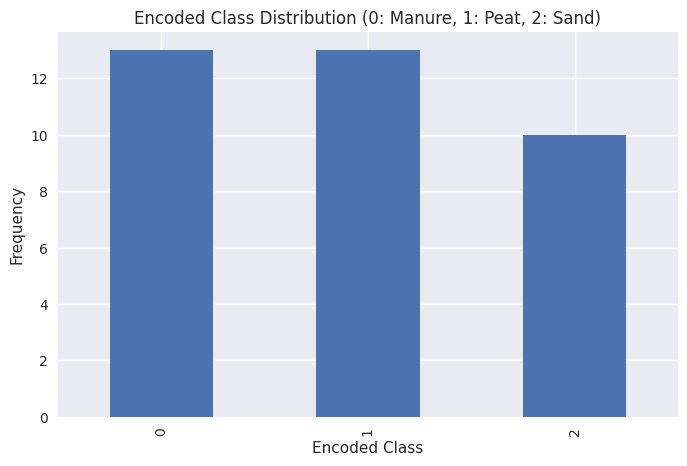

Columns with missing values: []

Number of features with 0.0 importance: 456

X_reduced.shape is  (36, 52)

X_reduced names.shape is  52
['Paludibaculum', 'CL500-3', 'OLB12', 'Ohtaekwangia', 'Dyadobacter', 'Planifilum', 'CL500-29 marine group', 'SWB02', 'Luteolibacter', 'Planctomicrobium', 'Pirellula', 'Gemmata', 'JGI 0001001-H03', 'Ilumatobacter', 'Candidatus Solibacter', 'Kineobactrum', 'Croceibacterium', 'Sphingomonas', 'Sphingopyxis', 'Sphingorhabdus', 'Coxiella', 'Polycyclovorans', 'Pedomicrobium', 'Arsenicitalea', 'Bosea', 'Methyloceanibacter', 'Pseudomonas', 'Steroidobacter', 'Acidibacter', 'Dokdonella', 'Shinella', 'Bradyrhizobium', 'Aquicella', 'Buchnera', 'Asticcacaulis', 'Gaiella', 'Leptolyngbya ANT.L52.2', 'Geomonas', 'Xylophilus', 'Rubrivivax', 'MND1', 'Duganella', 'Massilia', 'Ferribacterium', 'Dechloromonas', 'Methylibium', 'Methylophilus', 'Achromobacter', 'mle1-7', 'Ellin6067', 'Oleiharenicola', 'Opitutus']
['Paludibaculum', 'CL500-3', 'OLB12', 'Ohtaekwangia', 'Dyadoba

In [7]:
# Load and transpose the main data
##### Load Normalized data, using DESeq2 software #####
# Aviti Normalized data 
X = pd.read_csv('Aviti_DESeq2_normalized_data.txt', delimiter='\t', index_col=0).T
# Miseq Normalized data 
# X = pd.read_csv('Miseq_DESeq2_normalized_data.txt', delimiter='\t', index_col=0).T
# Novaseq Normalized data 
# X = pd.read_csv('Novaseq_DESeq2_normalized_data.txt', delimiter='\t', index_col=0).T

print(X.head())

X.index = X.index.astype(str)

# Load metadata
metadata = pd.read_excel('Metadata.xlsx')

# Extract digits after the first 3 characters
metadata['Sample_num'] = metadata['Sample_name'].astype(str).str.slice(3).str.extract(r'(\d+)')[0]

### Based on the classification type (Autoclave, Heat root, Soil), uncomment one of the following 
# Create a mapping from numeric sample name → Autoclave type
# sample_to_condition = dict(zip(metadata['Sample_num'], metadata['Autoclave']))
# Create a mapping from numeric sample name → Heat root type
# sample_to_condition = dict(zip(metadata['Sample_num'], metadata['Heat root']))
# Create a mapping from numeric sample name → soil type
sample_to_condition = dict(zip(metadata['Sample_num'], metadata['Soil']))

# Map sample names in X to soil types
y_raw = X.index.map(sample_to_condition)

# Keep only samples with valid labels
valid_samples = y_raw.notna()
X = X[valid_samples]
y_raw = y_raw[valid_samples]
feature_names = X.columns.tolist()
# Encode soil types
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(dict(zip(le.classes_, le.transform(le.classes_))))

# Create a DataFrame showing sample names and their labels ---> for debugging purpose
labels_df = pd.DataFrame({
    'Sample_Name': X.index,
    'Soil_Type': y_raw.values,
    'Soil_Label': y
})

# Display the result
print("🧾 Sample names with their respective labels:")
print(labels_df)



print("Encoded Class Distribution:")
print(pd.Series(y).value_counts())
# Plot the class distribution
plt.figure(figsize=(8, 5))
pd.Series(y).value_counts().plot(kind='bar')
### Based on the classification type (Autoclave, Heat root, Soil), uncomment one of the following 
# when condition = soil
plt.title('Encoded Class Distribution (0: Manure, 1: Peat, 2: Sand)')
#  when condition = autoclave or Heat root
# plt.title('Encoded Class Distribution (0: No, 1: Yes)')
plt.xlabel('Encoded Class')
plt.ylabel('Frequency')
plt.show()

# Check for missing values --> there were none
print(f"Columns with missing values: {X.columns[X.isnull().any()].tolist()}")
# Feature selection
rf = RandomForestClassifier(n_estimators=15, random_state=42)
rf.fit(X, y)
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
# Count the number of features with 0.0 importance and print their names -----> only 46 is important out of 1017 when label is soil
zero_importance_features = feature_importances[feature_importances == 0.0].index.tolist()
print(f"\nNumber of features with 0.0 importance: {len(zero_importance_features)}")
# print("Features with 0.0 importance:", zero_importance_features)
# print("\nFeature Importances:")
# print(feature_importances.sort_values(ascending=False))
# Remove zero importance features from X
X = X.drop(columns=zero_importance_features) 
feature_names_reduced = X.columns.tolist()
print("\nX_reduced.shape is ", X.shape)
print("\nX_reduced names.shape is ", len(feature_names_reduced))
print(feature_names_reduced)

# ////////////////////////////// Select which features you want to use in the analysis ///////////////////////////////

# Pick a feature set from the "Feature Sets" section (next cell) to test and replace it with the desired_columns = [] below.
# desired_columns = []

# ****************New part, in this way we consider all non-zero-importance features 
# Assign ALL reduced features to your desired_columns
desired_columns = feature_names_reduced
# ****************end of the New part

# ////////////////////////////// end of Select which features you want to use in the analysis ///////////////////////////////

# print (features)
# print("len features now issssssss",len(features))

# uncomment the following line if you choose SHAP features in "desired_columns" (and not "X after removing zero-importance features")
print (desired_columns)
print("now issssssss",len(desired_columns))

print("************************************")
# print("Available columns:", X.columns.tolist())
print("Desired columns:", desired_columns)

missing = [col for col in desired_columns if col not in X.columns]
print("Missing columns:", missing)
print("************************************")

X = X[desired_columns]
feature_names_reduced = X.columns.tolist()
print(X.head())
# print(X_reduced.head())

### Feature Sets

In [ ]:
## 😁these are the shap features calculated from the "REDUCED Normalized FEATURES Version2"😁---> shap&RF
#### SHAP, Union of Aviti's soil features within 3 groups (uniques only) 🍳
# desired_columns =["Acidovorax","Agrobacterium","Azotobacter","C1-B045","Candidatus Solibacter","Cellvibrio","Chthonobacter",
# "Croceibacterium","Fermentimonas","Fimbriiglobus","Hyphomicrobium","Ideonella","Labrys","Methylobacter","Niveispirillum","Oligoflexus",
# "oc32","Parafilimonas","Planctopirus","Planifilum","Roseimaritima","Sneathiella","Spirochaeta 2","SWB02","Ureibacillus","Zavarzinella"]
#### SHAP, 3 top common features of Aviti's soil 🍳
# desired_columns =["Roseimaritima","SWB02","Croceibacterium"]
## SHAP, Aviti Autoclave 🍕
# desired_columns=['Gemmata','Neobacillus','Ramlibacter','Methanosarcina','Niallia','UBA6140','Imperialibacter',
# 'OLB13','Methylobacter','Flavobacterium','Stenotrophobacter','Telmatocola','Dysgonomonas','Blastocatella',
# 'Methyloversatilis','Pseudofulvimonas','Mesobacillus','Sphingomonas','Sulfurifustis','Reyranella']
#### SHAP, Aviti Heat Root 🎃
# desired_columns = ["YC-ZSS-LKJ147","Salinispira","Massilia","Algoriphagus","Microbacterium","Candidatus Arcanobacter",
# "Reyranella","Candidatus Ovatusbacter","Rhodopila","Candidatus Omnitrophus","Erythrobacter","Mesorhizobium","Lacihabitans",
# "Variovorax","Xylophilus","Pseudoduganella","Bradyrhizobium","Ramlibacter","OLB13","Mycobacterium"]

#### SHAP, Union of Miseq's soil features within 3 groups (uniques only) 🍳
# desired_columns =["Acidibacter","Arsenicitalea","Bosea","Bradyrhizobium","CL500-3","Croceibacterium","Dechloromonas","Dokdonella",
# "Ferribacterium","Gemmata","Geomonas","Ilumatobacter","JGI 0001001-H03","Kineobactrum","Luteolibacter","MND1","Methylophilus","OLB12",
# "Oleiharenicola","Opitutus","Planctomicrobium","Pseudomonas","Rubrivivax","Shinella","Sphingopyxis","Sphingorhabdus","Steroidobacter","SWB02"]
#### SHAP, 3 top common features of Miseq's soil 🍳
# desired_columns=['SWB02', 'Croceibacterium', 'CL500-3']
# ## SHAP, Miseq autoclave 🍕
# desired_columns=['Chryseolinea','Imperialibacter','Abditibacterium','YC-ZSS-LKJ147','Rhodoplanes','Methylobacillus',
# 'Candidatus Nitrosoarchaeum','mle1-7','Bauldia','Hirschia','Devosia','Ellin6055','Ferruginibacter','IS-44','Parageobacillus',
# 'Mesobacillus','Ramlibacter','Dinghuibacter','Hassallia','Dokdonella']
#### SHAP, Miseq Heat Root 🎃
# desired_columns = ['Ilumatobacter','Pedobacter','MND1','Oleiharenicola','Phaselicystis','Chitinophaga','Chryseotalea',
# 'Pseudolabrys','Agriterribacter','Hydrogenophaga','Opitutus','Hypericibacter','Pedomicrobium','Luteolibacter',
# 'YC-ZSS-LKJ147','Subgroup 10','Candidatus Solibacter', 'Lentzea','Methylotenera','Labrys']

#### SHAP, Union of Novaseq's soil features within 3 groups (uniques only) 🍳
# desired_columns = [
#     "Afipia", "Bauldia", "BIyi10", "Brevifollis", "Caldicoprobacter",
#     "Candidatus Berkiella", "DSSD61", "Dyadobacter", "Dyella",
#     "Hydrogenispora", "IS-44", "Inhella", "Ketobacter", "Methanosarcina",
#     "Microbacterium", "Pararhizobium", "Plot4-2H12", "Pseudarthrobacter",
#     "Rhodopila", "Ruminofilibacter", "Runella", "Solimonas", "Subgroup 10"]
#### SHAP, 3 top common features of Novaseq's soil 🍳
# desired_columns =['Inhella', 'Plot4-2H12', 'Candidatus Berkiella']
#### SHAP, Novaseq autoclave 🍕
# desired_columns=['Neobacillus','Ammoniphilus','Stenotrophobacter','Kribbella','Snodgrassella','Gemmata','BIyi10','Aminobacter',
# 'Cupriavidus','Immundisolibacter','[Aquaspirillum] arcticum group','Slackia','Noviherbaspirillum','Novosphingobium',
# 'Marinoscillum','Brevibacillus','Verrucosispora','Subgroup 10','Crocinitomix','OLB13']
#### SHAP, Novaseq Heat Root 🎃
# desired_columns = ["Algoriphagus","Kribbella","Apilactobacillus","CL500-3","Acinetobacter","Candidatus Nitrosoarchaeum",
# "Rhodovastum","Longimicrobium","Stenotrophobacter","Candidatus Omnitrophus" ,"Pararhizobium","Niallia","Noviherbaspirillum",
# "Ketobacter","Hassallia","Ferruginibacter","Aquicella","Hydrogenispora","Candidatus Xiphinematobacter","Meiothermus"]

# uncomment the following line if you choose SHAP features in "desired_columns" and not al features ones.
# X = X[desired_columns]

In [ ]:
## 😁these are the shap features calculated from the "REDUCED Normalized FEATURES Version2 ----> shap&LSVM"😁
#### SHAP, Union of Aviti's soil features within 3 groups (uniques only) 🍳
# desired_columns = ['Azotobacter', 'Labrys', 'Chthonobacter', 'Ideonella', 'Sphingorhabdus', 'Agrobacterium', 'Acidovorax', 'YC-ZSS-LKJ147',
# 'Parafilimonas', 'Gemmata', 'Sneathiella', 'Fimbriiglobus', 'C1-B045', 'Methylobacter', 'BIyi10', 'SWB02', 'Polycyclovorans', 'Croceibacterium',
# 'Candidatus Solibacter', 'Hyphomicrobium', 'Cellvibrio', 'Spirochaeta 2', 'Streptomyces', 'Opitutus']
#### SHAP, 3 top common features of Aviti's soil, using Borda count 🍳
# desired_columns =['SWB02', 'Gemmata', 'Opitutus']
## SHAP, Aviti Autoclave 🍕
# desired_columns= ["Flavobacterium","Sphingomonas","Arenimonas","Hassallia","Methylobacter","Ramlibacter","Rubrivivax",
#     "Gemmata","Stenotrophobacter","Pelotalea","Sediminibacterium","Paucibacter","UBA6140","Iamia","Acidiferrimicrobium",
#     "Hirschia","Niastella","Pseudorhodoplanes","Reyranella","Conexibacter"]
# #### SHAP, Aviti HeatRoot 🎃
# desired_columns = ["Terrimonas","Chryseotalea","Subgroup 10" ,"MND1","Arenimonas","Ramlibacter","Bradyrhizobium",
# "Sediminibacterium","Devosia","Gemmatimonas","Cellvibrio","Ohtaekwangia","Luteolibacter","YC-ZSS-LKJ147","Ferribacterium",
# "Algoriphagus","Variovorax", "Lentzea","Rhizobacter","Massilia"]

#### SHAP, Union of Miseq's soil features within 3 groups (uniques only) 🍳
# desired_columns = ['Ilumatobacter', 'CL500-3', 'Ohtaekwangia','Arsenicitalea', 'Dechloromonas', 'Geomonas', 'Pirellula', 'Sphingorhabdus',
# 'Paludibaculum', 'Dokdonella', 'Ellin6067', 'Acidibacter', 'Rubrivivax', 'Gemmata', 'Pedomicrobium', 'OLB12', 'MND1', 'Sphingomonas',
# 'Pseudomonas', 'SWB02', 'Polycyclovorans', 'Croceibacterium', 'JGI 0001001-H03', 'Kineobactrum', 'Oleiharenicola', 'Steroidobacter',
# 'Methylophilus', 'Shinella', 'Opitutus', 'Luteolibacter']
#### SHAP, 3 top common features of Miseq's soil, using Borda count 🍳
# desired_columns =['SWB02', 'Pseudomonas', 'Steroidobacter']
## SHAP, Miseq Autoclave 🍕
# desired_columns = ["IS-44","Dokdonella","Methylobacillus","Candidatus Solibacter","Ferruginibacter","Chthoniobacter","Devosia",
# "Hirschia","Bauldia","Ramlibacter","Chryseotalea","Phenylobacterium","Ellin6055","YC-ZSS-LKJ147","Panacibacter","Ellin517",
# "Luteolibacter",    "Pir4 lineage",    "Rhodoplanes","mle1-7"]
#### SHAP, Miseq HeatRoot 🎃
# desired_columns = ["UBA6140","Pseudomonas","Methylotenera","Oleiharenicola","Opitutus", "Croceibacterium","Candidatus Solibacter",
# "Dongia","MND1","Steroidobacter","Ilumatobacter","YC-ZSS-LKJ147","Pirellula","Sphingomonas","Subgroup 10","Reyranella",
# "Hassallia","Phenylobacterium","Chryseotalea","Ellin6067"]

#### SHAP, Union of Novaseq's soil features within 3 groups (uniques only) 🍳
# desired_columns = ['Subgroup 10', 'Dyadobacter', 'Dechloromonas', 'Inhella', 'Leeia', 'Pararhizobium', 'Arenimonas', 'Plot4-2H12',
# 'Microbacterium', 'Afipia', 'Hydrogenispora', 'Fimbriiglobus', 'Constrictibacter', 'Brevifollis', 'BIyi10', 'Candidatus Berkiella',
# 'DSSD61', 'Pseudarthrobacter', 'Bauldia', 'Ferribacterium', 'IS-44', 'Methyloceanibacter', 'Ketobacter']
#### SHAP, 3 top common features of Novaseq's soil, using Borda count 🍳
# desired_columns =['Subgroup 10', 'Fimbriiglobus', 'Bauldia']
#### SHAP, Novaseq autoclave 🍕
# desired_columns =["Ramlibacter","Gemmata","BIyi10","Novosphingobium","TM7a","Methylobacillus","Pseudomonas",
# "Algoriphagus","Marinoscillum","CL500-3","Subgroup 10","Kribbella","Aminobacter","Mesobacillus","Agrobacterium",
# "Cupriavidus","Asticcacaulis","Candidatus Protochlamydia","Niallia","Neobacillus"]
#### SHAP, Novaseq HeatRoot 🎃
# desired_columns = ["Shinella","CL500-3","Novosphingobium","Hassallia","Ahniella","Aquicella","Ferruginibacter","BIyi10",
# "Curvibacter","Acinetobacter","Chryseotalea","Rhodovastum","Solirubrobacter","Anaerolinea","Aeromicrobium","Candidatus Nitrosoarchaeum",
# "Steroidobacter","Algoriphagus","Noviherbaspirillum","Candidatus Omnitrophus"]

In [ ]:
#//////////////////////////////// SHAPG /////////////////////////////////////////
## 😁these are the shapG features calculated from the "REDUCED Normalized FEATURES Version2"😁---> SHAPG & RF
#### SHAPG, Union of Aviti's soil features within 3 groups (uniques only) 🍳
# desired_columns = ['Niveispirillum', 'SWB02', 'Roseimaritima', 'BIyi10', 'Ureibacillus', 'oc32', 'Polycyclovorans', 'C1-B045', 'Methylobacter',
# 'Sneathiella', 'Ideonella', 'Spirochaeta 2', 'YC-ZSS-LKJ147', 'Fimbriiglobus', 'Acidovorax', 'Pusillibacter', 'Croceibacterium',
# 'Chthonobacter', 'Zavarzinella', 'Zhengella', 'Planifilum', 'Sphingorhabdus', 'Agrobacterium', 'Azotobacter', 'Labrys', 'Gemmata',
# 'Candidatus Solibacter', 'Parafilimonas', 'Planctopirus', 'Fermentimonas']
#### SHAPG, 3 top common features of Aviti's soil 🍳
# desired_columns = ['Chthonobacter', 'Pusillibacter', 'SWB02']
## SHAPG, Aviti Autoclave 🍕
# desired_columns = ["Rhodovarius", "Xanthomonas", "Mesobacillus", "Kaistia", "Telmatocola", "Pseudofulvimonas", "Gemmata", "Imperialibacter",
# "Chthonobacter", "Emticicia", "Niallia", "Ramlibacter", "Reyranella", "Baekduia", "UBA6140", "BBMC-4", "Conexibacter", "Bdellovibrio",
# "AKYG587", "Neobacillus"]
#### SHAPG, Aviti Heat Root 🎃
# desired_columns = ["Micropepsis", "Thermaerobacter", "Lacihabitans", "Chryseotalea", "Algoriphagus", "Spirochaeta", "Acetobacter",
# "Thermobacillus", "Candidatus Arcanobacter", "[Polyangium] brachysporum group", "Niastella", "Salinispira", "Luteibacter", "Halocella","Phreatobacter",
# "Tepidanaerobacter", "Candidatus Bealeia", "Erythrobacter", "Massilia", "Leeia"]

#### SHAPG, Union of Miseq's soil features within 3 groups (uniques only) 🍳
# desired_columns = ['SWB02', 'Rubrivivax', 'Kineobactrum', 'Massilia', 'Planctomicrobium', 'Polycyclovorans', 'Ferribacterium',
# 'mle1-7', 'CL500-3', 'Sphingomonas', 'Shinella', 'Coxiella', 'Paludibaculum', 'Pseudomonas', 'Xylophilus', 'Duganella', 'Geomonas',
# 'Pirellula', 'Dechloromonas', 'OLB12', 'Luteolibacter', 'Croceibacterium', 'Bradyrhizobium', 'Methylophilus', 'Sphingorhabdus',
# 'Sphingopyxis', 'Pedomicrobium', 'Arsenicitalea', 'Gemmata', 'Methylibium', 'Asticcacaulis', 'JGI 0001001-H03', 'Dokdonella', 'Bosea',
# 'Gaiella', 'Ilumatobacter']
#### SHAPG, 3 top common features of Miseq's soil 🍳 ----> it only had 2 common features!
# desired_columns = ["Bradyrhizobium","Ilumatobacter"]
# ## SHAPG, Miseq autoclave 🍕
# desired_columns = ["mle1-7", "Imperialibacter", "Chryseotalea", "Dokdonella", "YC-ZSS-LKJ147", "Parageobacillus", "Ferruginibacter",
# "Hassallia", "Rhodoplanes", "Phenylobacterium", "Dinghuibacter", "Ilumatobacter", "Chryseolinea", "Abditibacterium", "Chthoniobacter","Bauldia",
# "Sumerlaea", "Hirschia", "Sediminibacterium", "Methylobacillus"]
#### SHAPG, Miseq Heat Root 🎃
# desired_columns = ["Cytophaga", "Spirochaeta 2", "Paludibaculum", "Tepidisphaera", "Chitinophaga", "Niastella", "Haliscomenobacter",
# "Ferruginibacter", "Chitinophaga", "Agriterribacter", "Pedobacter", "Bdellovibrio", "Pseudorhodoplanes", "Thermomonas", "Chryseotalea",
# "OLB12", "Hassallia", "Ureibacillus", "Phenylobacterium", "Luteolibacter"]


#### SHAPG, Union of Novaseq's soil features within 3 groups (uniques only) 🍳
# desired_columns = ['Rhodopila', 'Solimonas', 'Pararhizobium', 'BIyi10', 'Methanosarcina', 'Inhella', 'Dyella', 'Microbacterium',
# 'Ferribacterium', 'Runella', 'Ketobacter', 'Methyloceanibacter', 'Pseudarthrobacter', 'Bauldia', 'IS-44', 'Fimbriiglobus',
# 'Brevifollis', 'Plot4-2H12','DSSD61','Dechloromonas','Pusillibacter','Afipia','Cerasicoccus','Caldicoprobacter','Constrictibacter',
# 'Candidatus Berkiella', 'Ruminofilibacter', 'Dyadobacter', 'Hydrogenispora', 'Flavimaricola', 'Amaricoccus', 'Leeia']
#### SHAPG, 3 top common features of Novaseq's soil 🍳
# desired_columns = ['Candidatus Berkiella', 'Runella', 'Plot4-2H12']
#### SHAPG, Novaseq autoclave 🍕
# desired_columns = ["Mesobacillus", "Brucella", "Ruficoccus", "Kribbella", "Candidatus Protochlamydia", "Gemmata",
# "Noviherbaspirillum", "Desulfovibrio", "Snodgrassella", "Ramlibacter", "Immundisolibacter", "Ammoniphilus",
# "Subgroup 10", "Papillibacter", "Altericroceibacterium", "Sorangium", "Stenotrophobacter", "Aquisphaera",
# "Dechloromonas", "Methylobacillus"]
#### SHAPG, Novaseq Heat Root 🎃
# desired_columns = ["Erythrobacter","Algoriphagus","Lachnospiraceae UCG-004","Apilactobacillus", "Diaphorobacter","Phycocomes",
# "Desulfopila", "Phragmitibacter","Bordetella", "Meiothermus", "Actinokineospora", "Geothrix", "Fundidesulfovibrio",
# "Imperialibacter", "CL500-3", "Caedibacter", "Acrocarpospora", "Rhodovastum", "Skermanella", "Gemmobacter"]

In [ ]:
## 😁these are the shap features calculated from the "REDUCED Normalized FEATURES Version2 ----> SHAPG&LSVM"😁
#### SHAPg, Union of Aviti's soil features within 3 groups (uniques only) 🍳
# desired_columns = ['Niveispirillum', 'SWB02','Roseimaritima','BIyi10','Ureibacillus','oc32','Polycyclovorans','C1-B045',
# 'Methylobacter', 'Sneathiella', 'Ideonella', 'Spirochaeta 2', 'Fimbriiglobus', 'Cellvibrio', 'Acidovorax', 'Pusillibacter',
# 'Croceibacterium', 'Chthonobacter', 'Zavarzinella', 'Planifilum', 'Sphingorhabdus', 'Agrobacterium', 'Azotobacter','Hyphomicrobium',
# 'Labrys', 'Candidatus Solibacter', 'Gemmata', 'Parafilimonas', 'Planctopirus', 'Fermentimonas']
#### SHAPg, 3 top common features of Aviti's soil, using Borda count 🍳
# desired_columns=['BIyi10', 'Chthonobacter', 'SWB02']
## SHAPg, Aviti Autoclave 🍕
# desired_columns=["Xanthomonas","Mesobacillus","Pseudofulvimonas","Kaistia","Pusillibacter","Rhodovarius",
# "Imperialibacter","Baekduia","Methanosarcina","Aetherobacter","Pelotalea","Erythrobacter","OLB13","Hirschia",
# "BBMC-4","Niallia","Methylobacter","Niastella","Tepidisphaera","Emticicia"]
##### SHAPg, Aviti HeatRoot 🎃
# desired_columns = ["Erythrobacter","Salinispira","Acetobacter","Luteibacter","Spirochaeta","Propionicicella","Tepidanaerobacter",
# "Thermaerobacter","Leeia","[Polyangium] brachysporum group","Mycobacterium","OLB13","Lentzea","Roseateles","Sediminibacterium",
# "Lacihabitans","Candidatus Bealeia","Candidatus Ovatusbacter","Cavicella","Allocatelliglobosispora"]

#### SHAPG, Union of Miseq's soil features within 3 groups (uniques only) 🍳
# desired_columns = ['SWB02', 'Rubrivivax', 'Kineobactrum', 'Planctomicrobium', 'Massilia', 'Polycyclovorans', 'Ferribacterium', 'mle1-7',
# 'CL500-3','Sphingomonas', 'Shinella', 'Coxiella', 'Paludibaculum', 'Pseudomonas', 'CL500-29 marine group', 'Geomonas',
# 'Pirellula', 'Dechloromonas', 'Luteolibacter', 'OLB12', 'Acidibacter', 'Croceibacterium', 'Bradyrhizobium', 'Aquicella',
# 'Methylophilus', 'Sphingorhabdus', 'MND1', 'Sphingopyxis', 'Pedomicrobium', 'Arsenicitalea', 'Gemmata', 'Opitutus','JGI 0001001-H03',
# 'Dokdonella', 'Bosea', 'Gaiella', 'Ilumatobacter']
#### SHAPG, 3 top common features of Miseq's soil, using Borda count 🍳
# desired_columns = ['Dokdonella', 'SWB02', 'Methylophilus']
## SHAPG, Miseq Autoclave 🍕
# desired_columns = ["Mesobacillus","mle1-7","YC-ZSS-LKJ147","Imperialibacter","Panacagrimonas","Dinghuibacter",
# "Parageobacillus","Chryseotalea","Rhodoplanes","Abditibacterium","Hassallia","Ferruginibacter","Chryseobacterium","Bauldia",
# "Chthoniobacter","Chryseolinea","Dokdonella","Lelliottia","Aquicella","Methyloceanibacter"]
#### SHAPG, Miseq HeatRoot 🎃
# desired_columns = ["Pelagibius", "YC-ZSS-LKJ147", "Methylotenera", "UBA6140", "Hydrogenophaga",
# "Pseudolabrys", "Rhodoferax", "Aetherobacter", "Pedobacter", "Phaselicystis", "Ilumatobacter","Paludibaculum",
# "Chthonobacter", "Cereibacter", "Cytophaga", "Ellin6055","Gemmobacter", "Legionella", "Ferruginibacter", "Ureibacillus"]

#### SHAPG, Union of Novaseq's soil features within 3 groups (uniques only) 🍳
# desired_columns = ['Methanosarcina', 'Solimonas', 'Pararhizobium', 'BIyi10', 'Inhella', 'Dyella', 'Microbacterium', 'Ferribacterium', 'Runella',
# 'Ketobacter','Methyloceanibacter', 'Pseudarthrobacter', 'Bauldia', 'IS-44', 'Fimbriiglobus', 'Brevifollis', 'Plot4-2H12', 'DSSD61', 'Dechloromonas',
#  'Pusillibacter', 'Afipia', 'Cerasicoccus', 'Subgroup 10', 'Caldicoprobacter', 'Constrictibacter', 'Ruminofilibacter', 'Flavimaricola',
#  'Dyadobacter', 'Hydrogenispora', 'Candidatus Berkiella', 'Amaricoccus', 'Leeia']
#### SHAPG, 3 top common features of Novaseq's soil, using Borda count 🍳
# desired_columns = ['Methyloceanibacter', 'Constrictibacter', 'Plot4-2H12']
#### SHAPG, Novaseq autoclave 🍕
# desired_columns = ["Mesobacillus", "Brucella", "Candidatus Protochlamydia", "Ammoniphilus", "Immundisolibacter",
# "Desulfovibrio", "Aquisphaera", "Brevibacillus", "Niallia", "Snodgrassella","Crocinitomix", "OLB13", "Taonella", "Pseudoxanthobacter",
# "Cupriavidus", "Povalibacter", "Sandaracinobacter", "Asticcacaulis", "Ramlibacter", "Sorangium"]
#### SHAPG, Novaseq HeatRoot 🎃
# desired_columns = ["Erythrobacter", "Verticiella", "Lachnospiraceae UCG-004", "Phragmitibacter", "Meiothermus",
# "Phycocomes", "Desulfopila", "Diaphorobacter", "Caedibacter", "Kribbella", "Geothrix","Aquicella", "Actinokineospora",
# "Bordetella", "Tuberibacillus", "Fundidesulfovibrio","Thermoclostridium","Hydrogenispora","Edaphocola", "Novosphingobium"]


#### Train & Test Split

In [8]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Show the shapes of the splits
print("📊 Train set shape:", X_train.shape)
print("📊 Test set shape:", X_test.shape)


📊 Train set shape: (27, 52)
📊 Test set shape: (9, 52)


#### Random Forest Classifier

Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Cross-Validation Scores from GridSearchCV:
      mean_test_score  std_test_score  \
0           0.960000        0.080000   
1           0.960000        0.080000   
2           0.960000        0.080000   
3           1.000000        0.000000   
4           0.960000        0.080000   
..               ...             ...   
283         1.000000        0.000000   
284         0.846667        0.148474   
285         0.960000        0.080000   
286         0.960000        0.080000   
287         0.960000        0.080000   

                                                params  
0    {'max_depth': None, 'max_features': 'sqrt', 'm...  
1    {'max_depth': None, 'max_features': 'sqrt', 'm...  
2    {'max_depth': None, 'max_features': 'sqrt', 'm...  
3    {'max_depth': None, 'max_features': 'sqrt', 'm...  
4    {'max_depth': None, 'max_features': '

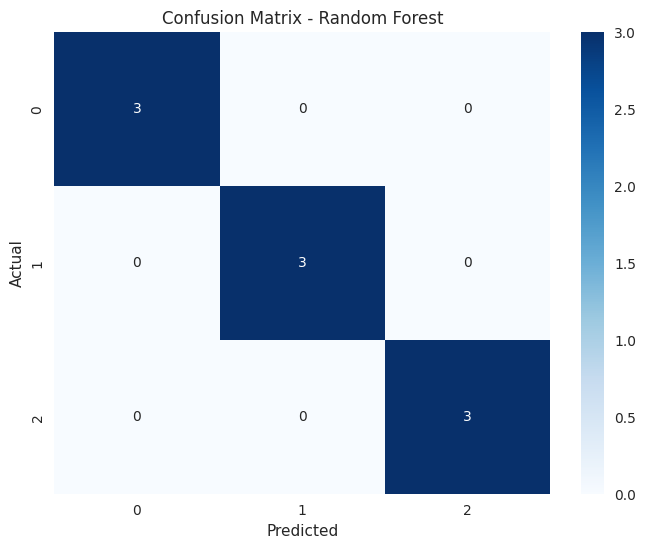

Model classes: [0 1 2]


In [9]:
# Hyperparameter Tuning and Cross-Validation for Random Forest
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
# Set a random_state for reproducibility
random_state = 42
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
best_params_rf = grid_search_rf.best_params_
print("Best parameters for Random Forest:", best_params_rf)

# Print Cross-Validation Scores from GridSearchCV
cv_results_rf = pd.DataFrame(grid_search_rf.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results_rf[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best Random Forest model
rf_model = RandomForestClassifier(**best_params_rf,random_state=random_state)

# Train the model on the entire training set
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)


# Model Evaluation for Random Forest
print("\nRandom Forest - Test Set Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Test Set Classification Report:")
print(classification_report(y_test, y_pred_rf))

# make sure the labels match
print("Unique values in y_test:", np.unique(y_test))

# Confusion Matrix
class_labels = rf_model.classes_
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

####### Use this for  a normal SHAP analysis in a binary classification task ########
# SHAP Analysis, on train set. Use the following codes only for "Autoclave" and "Heat root" that have binary values
# Use TreeExplainer for Random Forest
# explainer_rf = shap.TreeExplainer(rf_model)

# # Calculate SHAP values
# shap_values_rf = explainer_rf.shap_values(X_train)
# print("Random Forest shap_values shape is", np.shape(shap_values_rf))

# # Select the SHAP values for the positive class (class 1/yes)
# shap_values_rf_selected = shap_values_rf[:, :, 1]
# # Print the shape of the resulting array
# print("Selected SHAP values shape:", shap_values_rf_selected.shape)

# # Create an Explanation object
# shap_values_rf_explanation = shap.Explanation(
#     shap_values_rf_selected,
#     base_values=explainer_rf.expected_value[1],  # Use the expected value of the positive class
#     data=X_train,
#     # feature_names=feature_names
#     feature_names=feature_names_reduced
# )

# # Generate SHAP plots for the Train set
# # Summary Plot
# # shap.summary_plot(shap_values_rf_explanation, X_train, feature_names=feature_names)
# shap.summary_plot(shap_values_rf_explanation, X_train, feature_names=feature_names_reduced)
# # Bar Plot
# shap.plots.bar(shap_values_rf_explanation)

# # Beeswarm Plot
# shap.plots.beeswarm(shap_values_rf_explanation)

# # # Waterfall Plot for the first instance
# # shap.plots.waterfall(shap_values_rf_explanation[0])

print("Model classes:", rf_model.classes_)

#### SHAP Plots, Use the following cell when "Soil" is the intended label, which has 3 values ---> For RandomForest

In [49]:
# # Use TreeExplainer for Random Forest, on the train set
# explainer_rf = shap.TreeExplainer(rf_model)
# # Calculate SHAP values
# # shap_values_rf = explainer_rf.shap_values(X_test)
# shap_values_rf = explainer_rf.shap_values(X_train)
# print("Random Forest shap_values shape is", np.shape(shap_values_rf))

# # Ensure X_train is an array
# X_train_array = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
# print(X_train_array)
# # Check the shape of shap_values_rf
# print("SHAP values shape:", shap_values_rf.shape)

# # Generate all SHAP plots for each class
# for i in range(shap_values_rf.shape[2]):
#     print(f"Generating SHAP plots for Class: {le.classes_[i]}")

#     # Ensure the shapes match for the summary plot
#     class_shap_values = shap_values_rf[:, :, i]
    
#     # Create an Explanation object for the current class
#     shap_explanation = shap.Explanation(
#         values=class_shap_values,  # SHAP values for class i
#         base_values=explainer_rf.expected_value[i],  # Base values for class i
#         # data=X_test_array,
#         data=X_train_array,
#         feature_names=feature_names_reduced
#         # feature_names=feature_names
#     )

#     # Summary Plot
#     # shap.summary_plot(shap_explanation,X_train_array, feature_names=feature_names, class_names=le.classes_)
#     shap.summary_plot(shap_explanation, X_train_array, feature_names=feature_names_reduced, class_names=le.classes_)

#     # Bar Plot
#     shap.plots.bar(shap_explanation, max_display=10)

#     # Beeswarm Plot
#     shap.plots.beeswarm(shap_explanation)

#     # # Waterfall Plot for the first instance
#     # shap.plots.waterfall(shap_explanation[0])



### SVM

In [9]:
# # Hyperparameter grid for SVM
# param_grid_svm = {
#     'C': [0.01, 0.1, 1, 10, 30],
#     'kernel': ['linear'],
#     'gamma': ['scale', 'auto']  # relevant for RBF
# }
# random_state = 42

# # Grid search with 5-fold CV
# grid_search_svm = GridSearchCV(SVC(probability=True, random_state=random_state),
#                                param_grid_svm, cv=5, scoring='accuracy')
# grid_search_svm.fit(X_train, y_train)

# best_params_svm = grid_search_svm.best_params_
# print("Best parameters for SVM:", best_params_svm)

# # Cross-validation results
# cv_results_svm = pd.DataFrame(grid_search_svm.cv_results_)
# print("\nCross-Validation Scores from GridSearchCV:\n", cv_results_svm[['mean_test_score', 'std_test_score', 'params']])

# # Train best model on full training set
# model_svm = SVC(**best_params_svm, probability=True, random_state=random_state,max_iter=10000)
# model_svm.fit(X_train, y_train)


# # Predictions on test set
# y_pred_svm = model_svm.predict(X_test)

# # Standard prediction evaluation
# print("\nStandard SVM - Test Set Accuracy:", accuracy_score(y_test, y_pred_svm))
# print("Test Set Classification Report:")
# print(classification_report(y_test, y_pred_svm))

# # Confusion Matrix for SVM predictions
# conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
# plt.figure(figsize=(8, 6))
# sns.heatmap(conf_matrix_svm, annot=True, fmt="d", cmap="Blues",
#             xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
# plt.title("Confusion Matrix - Standard SVM")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # # SHAP Analysis, on train set. Use the following codes only for "Autoclave" and "Heat root" that have binary values
# # # Select the appropriate explainer
# # # SHAP explainer setup
# # if best_params_svm['kernel'] == 'linear':
# #     explainer_svm = shap.LinearExplainer(model_svm, X_train)
# #     shap_values_svm = explainer_svm.shap_values(X_train)
# #     base_values_svm = np.full(shap_values_svm.shape[0], explainer_svm.expected_value)
# #     expl_svm = shap.Explanation(
# #         shap_values_svm,
# #         base_values=base_values_svm,
# #         data=X_train,
# #         # feature_names=feature_names
# #         feature_names=feature_names_reduced
# #     )
# # else:
# #     def svm_proba(X):
# #         return model_svm.predict_proba(X)
# #     background = shap.sample(X_train, 100)
# #     explainer_svm = shap.KernelExplainer(svm_proba, background)
# #     shap_values_svm = explainer_svm.shap_values(X_train, nsamples=100)

# #     # Combine per-instance explanations for one class (e.g. class 1)
# #     shap_matrix = np.array([row[:,1] for row in shap_values_svm])
# #     base_values_svm = np.full(shap_matrix.shape[0], explainer_svm.expected_value[1])
# #     expl_svm = shap.Explanation(
# #         shap_matrix,
# #         base_values=base_values_svm,
# #         data=X_train,
# #         # feature_names=feature_names
# #         feature_names=feature_names_reduced
# #     )

# # # 🧠 SHAP visualizations
# # # shap.summary_plot(expl_svm.values, X_train, feature_names=feature_names,max_display=20)
# # shap.summary_plot(expl_svm.values, X_train, feature_names=feature_names_reduced,max_display=20)
# # shap.plots.bar(expl_svm, max_display=10)
# # shap.plots.beeswarm(expl_svm)
# # # # shap.plots.waterfall(expl_svm[1])




#### SHAP Plots, Use the following cell when "Soil" is the intended label, which has 3 values ---> For SVM

In [ ]:
# # Use TreeExplainer for Random Forest, on the train set
# explainer_svm = shap.LinearExplainer(model_svm, X_train)
# # Calculate SHAP values
# # shap_values_svm = explainer_svm.shap_values(X_test)
# shap_values_svm = explainer_svm.shap_values(X_train)
# print("SVM shap_values shape is", np.shape(shap_values_svm)) 

# # Ensure X_train is an array
# X_train_array = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
# print(X_train_array)
# # Check the shape of shap_values_svm
# print("SHAP values shape:", shap_values_svm.shape)

# # Generate all SHAP plots for each class
# for i in range(shap_values_svm.shape[2]):
#     print(f"Generating SHAP plots for Class: {le.classes_[i]}")

#     # Ensure the shapes match for the summary plot
#     class_shap_values = shap_values_svm[:, :, i]
    
#     # Create an Explanation object for the current class
#     shap_explanation = shap.Explanation(
#         values=class_shap_values,  # SHAP values for class i
#         base_values=explainer_svm.expected_value[i],  # Base values for class i
#         # data=X_test_array,
#         data=X_train_array,
#         feature_names=feature_names_reduced
#         # feature_names=feature_names
#     )

#     # Summary Plot
#     # shap.summary_plot(shap_explanation,X_train_array, feature_names=feature_names, class_names=le.classes_)
#     shap.summary_plot(shap_explanation, X_train_array, feature_names=feature_names_reduced, class_names=le.classes_)

#     # Bar Plot
#     shap.plots.bar(shap_explanation, max_display=10)

#     # Beeswarm Plot
#     shap.plots.beeswarm(shap_explanation)

#     # # Waterfall Plot for the first instance
#     # shap.plots.waterfall(shap_explanation[0])


## ShapG plots

#### shapG forceplot, binary RF cases
##### Execute this when you want plots for 1 sample in test set ---> not used in the paper 

In [9]:
# # ============================================================
# # SHapG: Graph + SamplerExplainer + SHAP Force Plots
# # ============================================================

# from shapG import GraphBuilder
# import numpy as np
# import shap
# import sys, os

# # ------------------------------------------------------------
# # 1. Build ShapG graph
# # ------------------------------------------------------------
# builder = GraphBuilder()

# G = builder.from_rank_deletion(
#     X_train, y_train,
#     density_ratio=None,
#     correlation_method='cosine',
#     similarity_method='cosine'
# )

# print("ShapG Graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# # ------------------------------------------------------------
# # 2. SamplerExplainer (per‑sample ShapG Shapley values)
# # ------------------------------------------------------------

# # Make sure strategy_inputs repo is cloned:
# # git clone https://github.com/vectorsss/strategy_inputs.git

# # Metric for force plots: use model output
# def model_output_metric(y_true, y_pred):
#     if y_pred.ndim == 1:
#         y_pred = y_pred.reshape(-1, 1)
#     return y_pred

# collaborator_map = SamplerExplainer.graph_to_collaborator_map(G)

# explainer_shapg = SamplerExplainer(
#     model=rf_model,
#     metric=model_output_metric,
#     collaborator_map=collaborator_map,
#     feature_names=feature_names_reduced,
#     mask_value=X_train.mean().values,
#     is_global_metric=False,
#     max_collaborator_subset=5,
# )

# shapg_dict = explainer_shapg.explain(X_test, y_test, verbose=True)

# # ------------------------------------------------------------
# # 3. Convert ShapG dict → matrix
# # ------------------------------------------------------------
# shapg_matrix = np.zeros((len(X_test), len(feature_names_reduced)))

# for feat_name, values in shapg_dict.items():
#     idx = feature_names_reduced.index(feat_name)
#     shapg_matrix[:, idx] = values.flatten()

# # ------------------------------------------------------------
# # 4. Wrap into SHAP Explanation object
# # ------------------------------------------------------------
# base_value = rf_model.predict_proba(X_train)[:, 1].mean()

# explanation_shapg = shap.Explanation(
#     values=shapg_matrix,
#     base_values=np.full(len(X_test), base_value),
#     data=X_test.values,
#     feature_names=feature_names_reduced
# )

# # ------------------------------------------------------------
# # 5. Visualizations (ShapG values using SHAP plots)
# # ------------------------------------------------------------


# # Bar plot
# shap.plots.bar(explanation_shapg)
# # Beeswarm
# shap.plots.beeswarm(explanation_shapg, max_display=20)


# print("ShapG values for sample 0:")
# print(shapg_matrix[0])

# # Force plot for a single sample
# import matplotlib.pyplot as plt

# # Create the force plot with matplotlib=True
# values_rounded = np.round(shapg_matrix[0], 2)
# data_rounded   = np.round(X_test.iloc[0].values, 2)

# shap.force_plot(
#     round(base_value, 2),
#     values_rounded,
#     data_rounded,
#     feature_names=feature_names_reduced,
#     matplotlib=True
# )





#### shapG forceplot, Multi-class RF case (soil)
##### Execute this when you want plots for 1 sample in test set ---> not used in the paper 

In [51]:
# # ============================================================
# # SHapG: Graph + SamplerExplainer + SHAP Force Plots (Random Forest, Multiclass)
# # ============================================================

# import numpy as np
# import shap
# import matplotlib.pyplot as plt
# from shapG import GraphBuilder

# # 1. Train Random Forest (already fitted earlier as rf_model)

# # 2. Build ShapG graph
# builder = GraphBuilder()
# G = builder.from_rank_deletion(
#     X_train, y_train,
#     density_ratio=None,
#     correlation_method='cosine',
#     similarity_method='cosine'
# )
# print("ShapG Graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# # 3. SamplerExplainer setup
# def model_output_metric(y_true, y_pred):
#     if y_pred.ndim == 1:
#         y_pred = y_pred.reshape(-1, 1)
#     return y_pred

# collaborator_map = SamplerExplainer.graph_to_collaborator_map(G)
# explainer_shapg = SamplerExplainer(
#     model=rf_model,
#     metric=model_output_metric,
#     collaborator_map=collaborator_map,
#     feature_names=feature_names_reduced,
#     mask_value=X_train.mean().values,
#     is_global_metric=False,
#     max_collaborator_subset=5,
# )

# # 4. Compute ShapG Shapley values
# shapg_dict = explainer_shapg.explain(X_test, y_test, verbose=True)
# shapg_matrix = np.zeros((len(X_test), len(feature_names_reduced)))
# for feat_name, values in shapg_dict.items():
#     idx = feature_names_reduced.index(feat_name)
#     shapg_matrix[:, idx] = values.flatten()

# # 5. Base values for each class (multiclass)
# base_values = rf_model.predict_proba(X_train).mean(axis=0)  # shape (n_classes,)
# print("Base values per class:", base_values)

# # 6. Wrap into SHAP Explanation
# explanation_shapg = shap.Explanation(
#     values=shapg_matrix,
#     base_values=np.tile(base_values, (len(X_test), 1)),  # repeat for each sample
#     data=X_test.values,
#     feature_names=feature_names_reduced
# )

# # 7. Global visualizations
# shap.plots.bar(explanation_shapg)
# shap.plots.beeswarm(explanation_shapg)

# # 8. Force plots for each class (multiclass)
# sample_index = 0
# data_rounded   = np.round(X_test.iloc[sample_index].values, 2)
# values_rounded = np.round(shapg_matrix[sample_index], 2)

# class_names = le.classes_  # from your LabelEncoder

# for class_idx, class_name in enumerate(class_names):
#     print (class_name)
#     shap.force_plot(
#         round(base_values[class_idx], 2),
#         values_rounded,
#         data_rounded,
#         feature_names=feature_names_reduced,
#         matplotlib=True
#     )
#     plt.gcf().set_size_inches(12, 4)
#     plt.tight_layout()
#     plt.savefig(f"forceplot_sample{sample_index}_class{class_name}.png",
#                 dpi=300, bbox_inches='tight')
#     plt.show()


#### ShapG for Binary Classification task (Autoclave & Heat Root), RF
##### Execute this when you want plots for All samples  the train set (all_features - zero-importance ones) ---> Used in the paper

In [7]:
# X_train_df = pd.DataFrame(X_train, columns=X.columns)


# # # --- NEW: SHAPG Analysis on the Training Set Only ---

# # Step 1: Build the similarity matrix (and graph) using only the training data.
# # This means we only capture feature relationships as seen on X_train.
# W = matrix_generator(X_train_df, kl)
# A, W_new = create_minimal_edge_graph(W, reverse=True, version='v3')
# G = nx.Graph(A)

# # Step 2: Redefine the characteristic function to use only the training set.
# # Here we use an internal train/validation split on X_train & y_train 
# # to evaluate the performance of each feature subset.

# def classification_kpi(G, S):
#     """
#     Characteristic function for SHAPG XAI on the training set.
#     It splits X_train (only the selected columns) into an inner train/validation,
#     trains a logistic regression model (using your tuned hyperparameters),
#     and returns the evaluation score (F1 score) on the validation set.
    
#     Args:
#         G (nx.Graph): The feature graph (not directly used in the function).
#         S (list): A list of feature names (columns) in X_train.
    
#     Returns:
#         float: The F1 score for the model trained on the subset S.
#     """
#     cols = list(S)
#     if len(cols) == 0:
#         return 0
#     else:
#         # Internal split on training data only:
#         X_train_sub, X_val, y_train_sub, y_val = train_test_split(
#             X_train_df[cols], y_train, test_size=0.2, random_state=42
#         )
#         # Use a fixed logistic regression with your best-tuned parameters:
#         # Initialize the best Random Forest model
#         model_kpi_rf = RandomForestClassifier(**best_params_rf,random_state=random_state)
#         model_kpi_rf.fit(X_train_sub, y_train_sub)
#         y_pred_rf = model_kpi_rf.predict(X_val)
#         # For binary or multi-class classification, choose the appropriate averaging.
#         score = f1_score(y_val, y_pred_rf, average='binary')
#         return score

# # Step 3: Run the SHAPG algorithm using the feature graph G and your new KPI function.
# shapley_value_rf = shapley(G, m=3, f=classification_kpi, approximate_by_ratio=True)

# # Step 4: Visualize the SHAPG results.
# fig, ax = shapGplot(shapley_value_rf, top_n=20, show_plot=False)
# ax.set_xlabel("Feature importance", fontsize=14)
# ax.set_ylabel("Features", fontsize=14)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.set_title('Top 20 Influential Features (SHAPG on Training Set)', fontsize=16)
# plt.show()


# # --- NEW: Add this to the bottom of Cell 1 ---

# import shap
# # Pick top 20 based on Step 3
# sorted_features = sorted(shapley_value_rf.items(), key=lambda x: x[1], reverse=True)
# top_20_names = [item[0] for item in sorted_features[:20]]

# # Create the explainer object (THIS WAS THE MISSING PART)
# def model_output_metric(y_true, y_pred):
#     return y_pred.reshape(-1, 1) if y_pred.ndim == 1 else y_pred

# explainer_shapg = SamplerExplainer(
#     model=rf_model,
#     metric=model_output_metric,
#     collaborator_map=SamplerExplainer.graph_to_collaborator_map(G),
#     feature_names=X_train_df.columns.tolist(), # Use ALL 59 names here
#     # feature_names=top_20_names,
#     mask_value=X_train_df.mean().values        # Use ALL 59 mean values here
#     # mask_value=X_train_df[top_20_names].mean().values
# )




# # Run explain on the FULL dataframe. 
# # (It might take slightly longer, but it's the safest way to avoid the error)
# shapg_train_dict = explainer_shapg.explain(X_train_df, y_train, verbose=True)

# # Then, when you build the matrix for the plot, you just extract the 20 you need:
# train_matrix = np.zeros((len(X_train_df), len(top_20_names)))
# for i, name in enumerate(top_20_names):
#     train_matrix[:, i] = shapg_train_dict[name]
# # 5. Local ShapG (The Beeswarm Dots)
# # We only explain the top 20 to save time
# # shapg_train_dict = explainer_shapg.explain(X_train_df[top_20_names], y_train, verbose=True)

# # 7. Create SHAP Explanation and Plot
# base_val_train = rf_model.predict_proba(X_train)[:, 1].mean()
# explanation_train = shap.Explanation(
#     values=train_matrix,
#     base_values=np.full(len(X_train_df), base_val_train),
#     data=X_train_df[top_20_names].values,
#     feature_names=top_20_names
# )

# # Create an array of indices [0, 1, 2, ..., 19] to tell SHAP 
# # to keep the current order and NOT re-sort by dot size.
# import numpy as np
# custom_order = np.arange(len(top_20_names))

# plt.figure(figsize=(10, 12))
# plt.title("ShapG Beeswarm (Ordered by Global Performance)", fontsize=16)

# # Use the indices for the order parameter
# shap.plots.beeswarm(explanation_train, max_display=20, order=custom_order)



#### shapG for multiclass Classification task (Soil), RF 
##### Execute this when you want plots for All samples in train set ---> Used in the paper


 CLASS: Manure
Computing GLOBAL ShapG...


/tmp/ipykernel_176386/2231792658.py:59: DeprecationWarning: shapG() is deprecated and will be removed in version 0.15.0. Please use ShapGExplainer instead: explainer = ShapGExplainer(depth=depth, n_samples=m); shapley_values = explainer.fit_explain(G)
  shapley_global = shapley(
/tmp/ipykernel_176386/2231792658.py:66: DeprecationWarning: The plot function from shapG.visualization is deprecated and will be removed in version 0.15.0. Please use FeatureImportanceVisualizer or plot_shapley_values instead.
  fig, ax = shapGplot(shapley_global, top_n=20, show_plot=False)


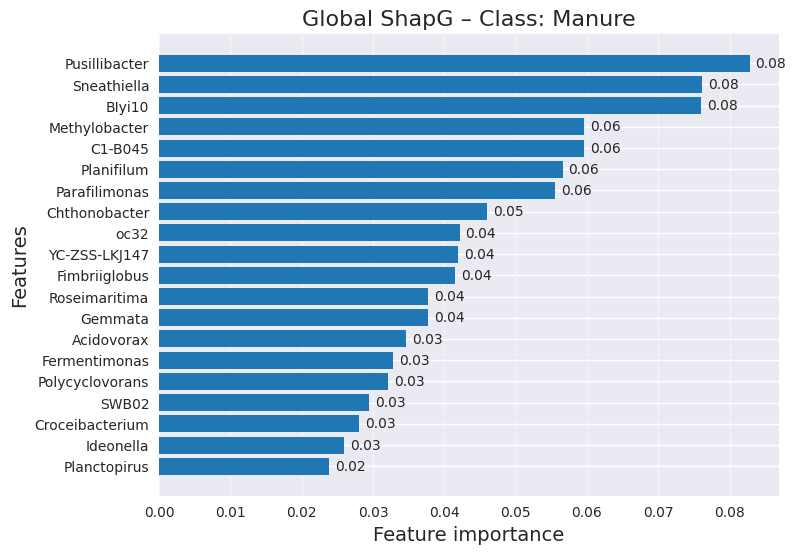

/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have 

Computing LOCAL ShapG...


/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have 

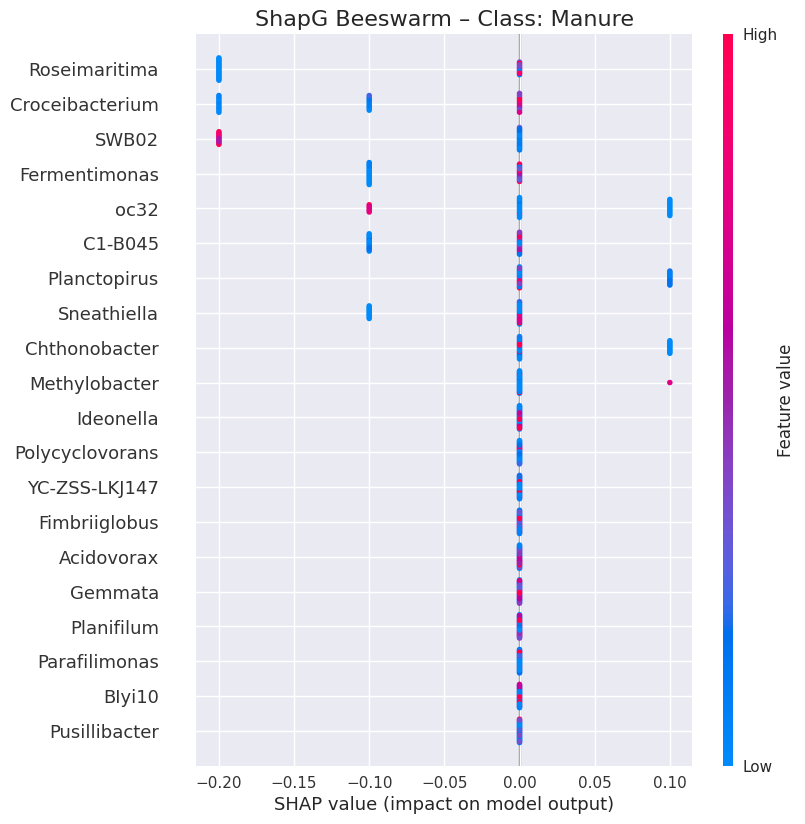

Finished class Manure

 CLASS: Peat
Computing GLOBAL ShapG...


/tmp/ipykernel_176386/2231792658.py:59: DeprecationWarning: shapG() is deprecated and will be removed in version 0.15.0. Please use ShapGExplainer instead: explainer = ShapGExplainer(depth=depth, n_samples=m); shapley_values = explainer.fit_explain(G)
  shapley_global = shapley(
/tmp/ipykernel_176386/2231792658.py:66: DeprecationWarning: The plot function from shapG.visualization is deprecated and will be removed in version 0.15.0. Please use FeatureImportanceVisualizer or plot_shapley_values instead.
  fig, ax = shapGplot(shapley_global, top_n=20, show_plot=False)


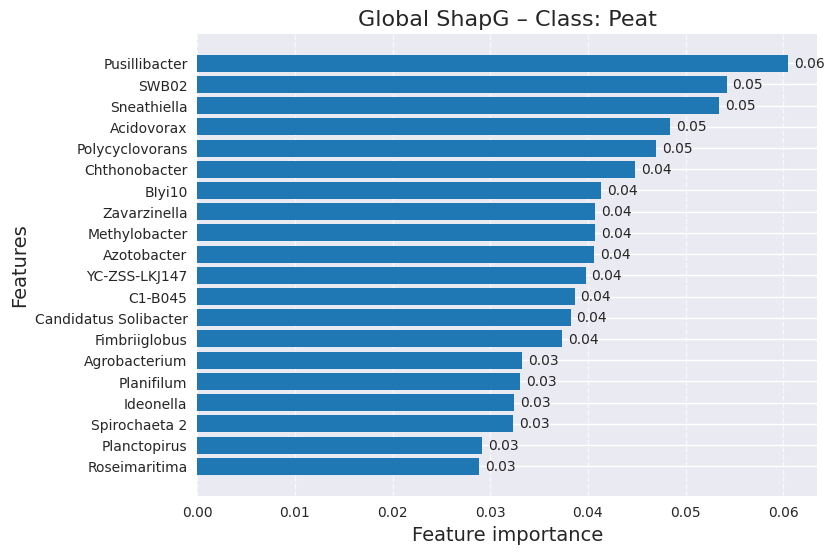

/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have 

Computing LOCAL ShapG...


/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have 

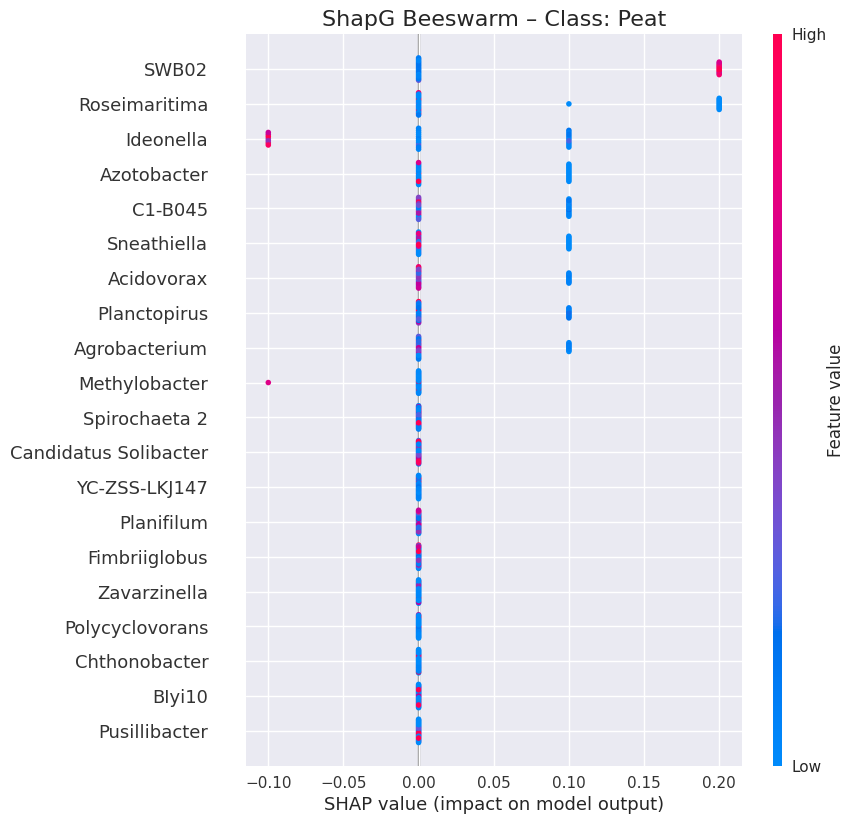

Finished class Peat

 CLASS: Sand
Computing GLOBAL ShapG...


/tmp/ipykernel_176386/2231792658.py:59: DeprecationWarning: shapG() is deprecated and will be removed in version 0.15.0. Please use ShapGExplainer instead: explainer = ShapGExplainer(depth=depth, n_samples=m); shapley_values = explainer.fit_explain(G)
  shapley_global = shapley(
/tmp/ipykernel_176386/2231792658.py:66: DeprecationWarning: The plot function from shapG.visualization is deprecated and will be removed in version 0.15.0. Please use FeatureImportanceVisualizer or plot_shapley_values instead.
  fig, ax = shapGplot(shapley_global, top_n=20, show_plot=False)


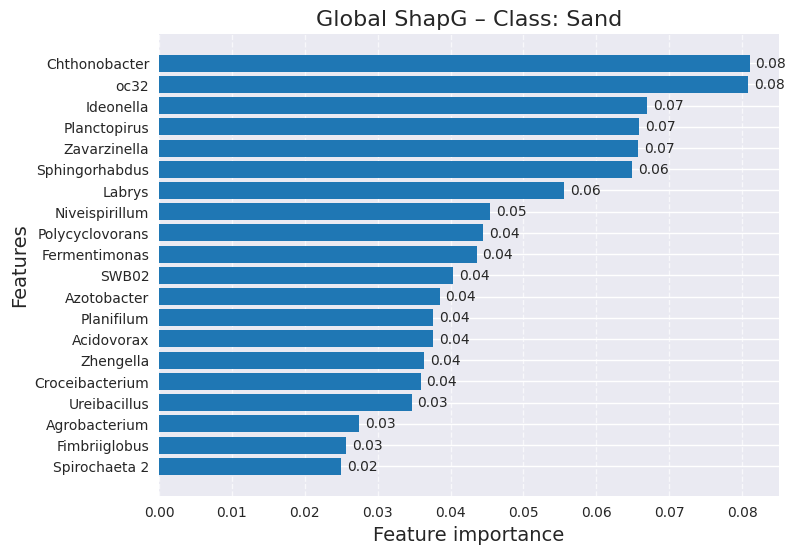

/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have 

Computing LOCAL ShapG...


/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fatemeh.hassanvand/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have 

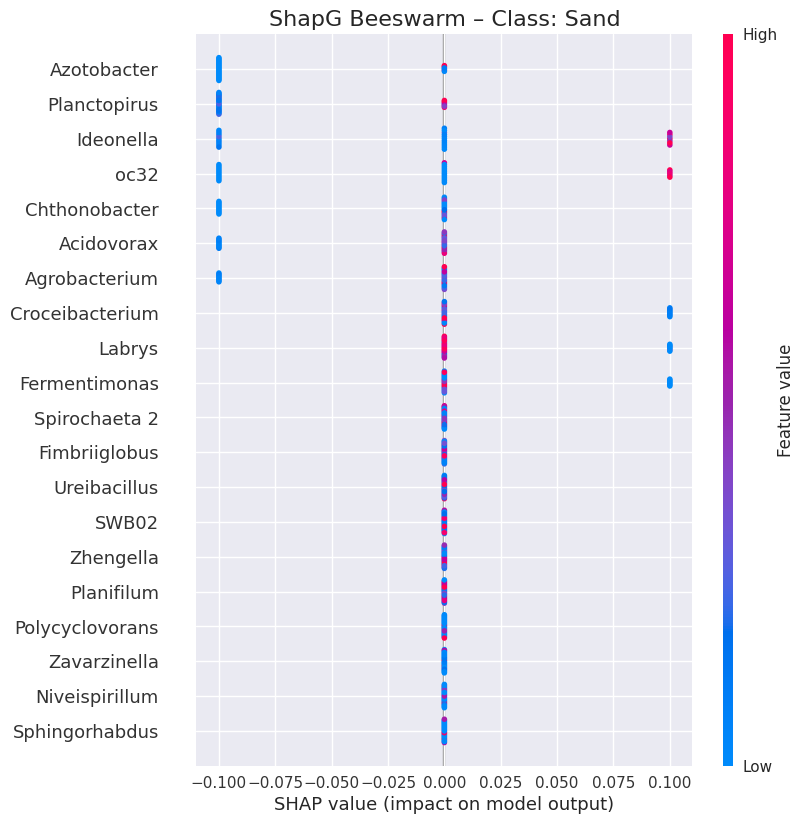

Finished class Sand


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# ============================================================
# 0. Prepare data
# ============================================================

X_train_df = pd.DataFrame(X_train, columns=X.columns)
feature_names = X_train_df.columns.tolist()
class_names = le.classes_   # e.g. ['A', 'B', 'C']

# ============================================================
# 1. Build ShapG graph ONCE
# ============================================================

W = matrix_generator(X_train_df, kl)
A, W_new = create_minimal_edge_graph(W, reverse=True, version='v3')
G = nx.Graph(A)

# ============================================================
# 2. Loop over classes
# ============================================================

for class_name in class_names:

    print(f"\n==============================")
    print(f" CLASS: {class_name}")
    print(f"==============================")

    # Convert class name → index
    class_idx = np.where(class_names == class_name)[0][0]

    # Create binary labels for this class
    y_binary = (y_train == class_idx).astype(int)

    # ============================================================
    # 3. GLOBAL SHAPG BAR PLOT
    # ============================================================

    print("Computing GLOBAL ShapG...")

    def classification_kpi(G, S):
        cols = list(S)
        if len(cols) == 0:
            return 0
        X_sub, X_val, y_sub, y_val = train_test_split(
            X_train_df[cols], y_binary, test_size=0.2, random_state=42
        )
        model_tmp = rf_model.__class__(**rf_model.get_params())
        model_tmp.fit(X_sub, y_sub)
        y_pred = model_tmp.predict(X_val)
        return f1_score(y_val, y_pred, average='binary')

    shapley_global = shapley(
        G,
        m=1,
        f=classification_kpi,
        approximate_by_ratio=True
    )

    fig, ax = shapGplot(shapley_global, top_n=20, show_plot=False)
    ax.set_title(f"Global ShapG – Class: {class_name}", fontsize=16)
    ax.set_xlabel("Feature importance", fontsize=14)
    ax.set_ylabel("Features", fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

    # Extract top 20 features from global ShapG
    sorted_features = sorted(shapley_global.items(), key=lambda x: x[1], reverse=True)
    top_features = [f for f, v in sorted_features[:20]]

    # ============================================================
    # 4. LOCAL SHAPG (BEESWARM)
    # ============================================================

    print("Computing LOCAL ShapG...")

    class ProbModelWrapper:
        def __init__(self, model, class_idx):
            self.model = model
            self.class_idx = class_idx

        def predict(self, X):
            return self.model.predict_proba(X)[:, self.class_idx]

    wrapped_model = ProbModelWrapper(rf_model, class_idx)

    def model_output_metric(y_true, y_pred):
        return y_pred.reshape(-1, 1)

    explainer_shapg = SamplerExplainer(
        model=wrapped_model,
        metric=model_output_metric,
        collaborator_map=SamplerExplainer.graph_to_collaborator_map(G),
        feature_names=feature_names,
        mask_value=X_train_df.mean().values,
        is_global_metric=False,
        max_collaborator_subset=5,
    )

    shapg_dict = explainer_shapg.explain(X_train_df, y_train, verbose=False)

    # Build matrix only for top features
    shapg_matrix = np.column_stack([shapg_dict[f] for f in top_features])

    base_val = rf_model.predict_proba(X_train_df)[:, class_idx].mean()

    explanation = shap.Explanation(
        values=shapg_matrix,
        base_values=np.full(len(X_train_df), base_val),
        data=X_train_df[top_features].values,
        feature_names=top_features,
    )

    plt.figure(figsize=(10, 10))
    plt.title(f"ShapG Beeswarm – Class: {class_name}", fontsize=16)
    shap.plots.beeswarm(explanation, max_display=20)
    plt.show()

    print(f"Finished class {class_name}")


### ShapG for Binary Classification task (Autoclave & Heat Root), SVM
##### Execute this when you want plots for All samples in the train set (all_features - zero-importance ones) ---> Used in the paper

In [20]:
# X_train_df = pd.DataFrame(X_train, columns=X.columns)

# # --- NEW: SHAPG Analysis on the Training Set Only ---

# # Step 1: Build the similarity matrix (and graph) using only the training data.
# # This means we only capture feature relationships as seen on X_train.
# W = matrix_generator(X_train_df, kl)
# A, W_new = create_minimal_edge_graph(W, reverse=True, version='v3')
# G = nx.Graph(A)

# # Step 2: Redefine the characteristic function to use only the training set.
# # Here we use an internal train/validation split on X_train & y_train 
# # to evaluate the performance of each feature subset.

# def classification_kpi(G, S):
#     """
#     Characteristic function for SHAPG XAI on the training set.
#     It splits X_train (only the selected columns) into an inner train/validation,
#     trains a logistic regression model (using your tuned hyperparameters),
#     and returns the evaluation score (F1 score) on the validation set.
    
#     Args:
#         G (nx.Graph): The feature graph (not directly used in the function).
#         S (list): A list of feature names (columns) in X_train.
    
#     Returns:
#         float: The F1 score for the model trained on the subset S.
#     """
#     cols = list(S)
#     if len(cols) == 0:
#         return 0
#     else:
#         # Internal split on training data only:
#         X_train_sub, X_val, y_train_sub, y_val = train_test_split(
#             X_train_df[cols], y_train, test_size=0.2, random_state=42
#         )
#         # Use a fixed logistic regression with your best-tuned parameters:
#         model_kpi = SVC(**best_params_svm, probability=True, random_state=random_state)
#         # model_kpi = LogisticRegression(**best_params_lr, max_iter=10000, tol=1e-3, random_state=random_state)
#         model_kpi.fit(X_train_sub, y_train_sub)
#         y_pred = model_kpi.predict(X_val)
#         # For binary or multi-class classification, choose the appropriate averaging.
#         score = f1_score(y_val, y_pred, average='binary')
#         return score

# # Step 3: Run the SHAPG algorithm using the feature graph G and your new KPI function.
# shapley_value = shapley(G, m=3, f=classification_kpi, approximate_by_ratio=False)

# # Step 4: Visualize the SHAPG results.
# fig, ax = shapGplot(shapley_value, top_n=20, show_plot=False)
# ax.set_xlabel("Feature importance", fontsize=14)
# ax.set_ylabel("Features", fontsize=14)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.set_title('Top 20 Influential Features (SHAPG on Training Set)', fontsize=16)
# plt.show()

# # --- STEP 5: Identify Top 20 features from the SHAPG Global ranking ---
# sorted_features = sorted(shapley_value.items(), key=lambda x: x[1], reverse=True)
# top_20_names = [item[0] for item in sorted_features[:20]]

# # --- STEP 6: Setup Explainer ---
# def model_output_metric(y_true, y_pred):
#     return y_pred.reshape(-1, 1) if y_pred.ndim == 1 else y_pred

# collaborator_map = SamplerExplainer.graph_to_collaborator_map(G)

# explainer_shapg = SamplerExplainer(
#     model=model_svm, # Ensure this is your final SVM trained with probability=True
#     metric=model_output_metric,
#     collaborator_map=collaborator_map,
#     feature_names=X_train_df.columns.tolist(),
#     mask_value=X_train_df.mean().values
# )

# # --- STEP 7: Calculate Local Values ---
# # Since you have 27 samples, we explain the whole set
# print(f"Calculating local SHAPG values for {len(X_train_df)} samples...")
# shapg_dict = explainer_shapg.explain(X_train_df, y_train, verbose=True)

# # --- STEP 8: Extract and Align the Matrix ---
# # We build the matrix specifically for the top_20_names in the correct order
# train_matrix = np.zeros((len(X_train_df), len(top_20_names)))

# for i, name in enumerate(top_20_names):
#     # Get the local contribution for this feature across all 27 samples
#     train_matrix[:, i] = shapg_dict[name].flatten()

# # --- STEP 9: Create the Explanation Object ---
# # Use the probability of the positive class for the base value
# base_val_svm = model_svm.predict_proba(X_train)[:, 1].mean()

# explanation_svm = shap.Explanation(
#     values=train_matrix,
#     base_values=np.full(len(X_train_df), base_val_svm),
#     data=X_train_df[top_20_names].values,
#     feature_names=top_20_names
# )

# # --- STEP 10: The Beeswarm Plot ---
# plt.figure(figsize=(10, 12))
# plt.title("ShapG Beeswarm: Top 20 Features (SVM)", fontsize=16)

# # This 'np.arange' trick forces SHAP to keep the order of top_20_names 
# # instead of re-sorting by the sum of the dots.
# custom_order = np.arange(len(top_20_names))

# shap.plots.beeswarm(
#     explanation_svm, 
#     max_display=20, 
#     order=custom_order,
#     show=False
# )

# # Clean up the plot aesthetics
# plt.xlabel("SHAP Value (Impact on Probability)", fontsize=12)
# plt.tight_layout()
# plt.show()

### ShapG for MultiClass Classification task (Soil), SVM
##### Execute this when you want plots for All samples in the train set (all_features - zero-importance ones) ---> Used in the paper

In [12]:
# import numpy as np
# import matplotlib.pyplot as plt
# import shap
# from sklearn.model_selection import train_test_split
# from sklearn.svm import SVC
# from sklearn.metrics import f1_score

# # Convert training data to DataFrame
# X_train_df = pd.DataFrame(X_train, columns=X.columns)

# # Build similarity matrix and feature graph
# W = matrix_generator(X_train_df, kl)
# A, W_new = create_minimal_edge_graph(W, reverse=True, version='v3')
# G = nx.Graph(A)

# # Loop through each class label for one-vs-rest SHAPG analysis
# for class_label in np.unique(y_train):
#     class_name = le.classes_[class_label]
#     print(f"\n🔍 Processing Class: {class_name}")

#     # 1. Create binary labels: 1 for current class, 0 for others
#     y_binary = (y_train == class_label).astype(int)

#     # 2. Define characteristic function (Using SVM)
#     def classification_kpi(G, S):
#         cols = list(S)
#         if len(cols) == 0: return 0
#         X_train_sub, X_val, y_train_sub, y_val = train_test_split(
#             X_train_df[cols], y_binary, test_size=0.2, random_state=42
#         )
#         # Using SVM with probability=True for the KPI evaluation
#         model_kpi_svm = SVC(**best_params_svm, probability=True, random_state=random_state)
#         model_kpi_svm.fit(X_train_sub, y_train_sub)
#         y_pred_svm = model_kpi_svm.predict(X_val)
#         return f1_score(y_val, y_pred_svm, average='binary')

#     # 3. Run Global SHAPG (The Bar Plot ranking)
#     # Using m=1 for speed with 52 features/27 samples; change to m=3 if you have time
#     shapley_value_svm = shapley(G, m=1, f=classification_kpi, approximate_by_ratio=True)

#     # 4. Show the Global Bar Plot
#     fig, ax = shapGplot(shapley_value_svm, top_n=20, show_plot=False)
#     ax.set_title(f'Global Importance (SVM): {class_name}', fontsize=16)
#     plt.show()

#     # --- BEESWARM SECTION ---

#     # 5. Get Top 20 names based on the Global ranking above
#     sorted_features = sorted(shapley_value_svm.items(), key=lambda x: x[1], reverse=True)
#     top_20_names = [item[0] for item in sorted_features[:20]]

#     # 6. Initialize the SamplerExplainer for the main SVM model
#     explainer_shapg = SamplerExplainer(
#         model=model_svm, # Your final trained SVC model
#         metric=lambda y_t, y_p: y_p.reshape(-1, 1) if y_p.ndim == 1 else y_p,
#         collaborator_map=SamplerExplainer.graph_to_collaborator_map(G),
#         feature_names=X_train_df.columns.tolist(),
#         mask_value=X_train_df.mean().values
#     )

#     # 7. Calculate Local contributions
#     print(f"   ⌛ Calculating Local contributions for {class_name}...")
#     shapg_train_dict = explainer_shapg.explain(X_train_df, y_binary, verbose=True)

#     # 8. Align the results into a matrix for the Beeswarm
#     train_matrix = np.zeros((len(X_train_df), len(top_20_names)))
#     for i, name in enumerate(top_20_names):
#         train_matrix[:, i] = shapg_train_dict[name].flatten()

#     # 9. Create the Explanation object
#     # Pull mean probability for the current SVM class
#     base_val_class = model_svm.predict_proba(X_train)[:, class_label].mean()
    
#     explanation_train = shap.Explanation(
#         values=train_matrix,
#         base_values=np.full(len(X_train_df), base_val_class),
#         data=X_train_df[top_20_names].values,
#         feature_names=top_20_names
#     )

#     # 10. Final Beeswarm Plot (Forced to match Bar Plot order)
#     plt.figure(figsize=(10, 10))
#     plt.title(f"Beeswarm Plot (SVM): {class_name}", fontsize=16)
#     shap.plots.beeswarm(explanation_train, max_display=20, order=np.arange(len(top_20_names)))
#     plt.show()
    
#     print(f"✅ Finished visualization for {class_name}\n" + "="*50)

#### shapG forceplot, Binary SVM cases (Autoclave & Heat Root)
#### Execute this when you want plots for 1 smaple in test set ---> not used in the paper

In [54]:
# # ============================================================
# # SHapG: Graph + SamplerExplainer + SHAP Force Plots (SVM)
# # ============================================================

# from shapG import GraphBuilder
# import numpy as np
# import shap
# import sys, os
# import matplotlib.pyplot as plt

# # ------------------------------------------------------------
# # 1. Build ShapG graph
# # ------------------------------------------------------------
# builder = GraphBuilder()

# G = builder.from_rank_deletion(
#     X_train, y_train,
#     density_ratio=None,
#     correlation_method='cosine',
#     similarity_method='cosine'
# )

# print("ShapG Graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# # ------------------------------------------------------------
# # 2. SamplerExplainer (per‑sample ShapG Shapley values)
# # ------------------------------------------------------------

# # Metric for force plots: use model output (probabilities from SVM)
# def model_output_metric(y_true, y_pred):
#     if y_pred.ndim == 1:
#         y_pred = y_pred.reshape(-1, 1)
#     return y_pred

# collaborator_map = SamplerExplainer.graph_to_collaborator_map(G)

# explainer_shapg = SamplerExplainer(
#     model=model_svm,   # <-- swapped in your SVM
#     metric=model_output_metric,
#     collaborator_map=collaborator_map,
#     feature_names=feature_names_reduced,
#     mask_value=X_train.mean().values,
#     is_global_metric=False,
#     max_collaborator_subset=5,
# )

# shapg_dict = explainer_shapg.explain(X_test, y_test, verbose=True)

# # ------------------------------------------------------------
# # 3. Convert ShapG dict → matrix
# # ------------------------------------------------------------
# shapg_matrix = np.zeros((len(X_test), len(feature_names_reduced)))

# for feat_name, values in shapg_dict.items():
#     idx = feature_names_reduced.index(feat_name)
#     shapg_matrix[:, idx] = values.flatten()

# # ------------------------------------------------------------
# # 4. Wrap into SHAP Explanation object
# # ------------------------------------------------------------
# # For SVM, base value = mean predicted probability for the positive class
# base_value = model_svm.predict_proba(X_train)[:, 1].mean()

# explanation_shapg = shap.Explanation(
#     values=shapg_matrix,
#     base_values=np.full(len(X_test), base_value),
#     data=X_test.values,
#     feature_names=feature_names_reduced
# )

# # ------------------------------------------------------------
# # 5. Visualizations (ShapG values using SHAP plots)
# # ------------------------------------------------------------

# # Bar plot
# shap.plots.bar(explanation_shapg)
# # Beeswarm
# shap.plots.beeswarm(explanation_shapg)

# print("ShapG values for sample 0:")
# print(np.round(shapg_matrix[0], 2))

# # Force plot for a single sample
# values_rounded = np.round(shapg_matrix[0], 2)
# data_rounded   = np.round(X_test.iloc[0].values, 2)

# shap.force_plot(
#     round(base_value, 2),
#     values_rounded,
#     data_rounded,
#     feature_names=feature_names_reduced,
#     matplotlib=True
# )

# plt.gcf().set_size_inches(12, 4)
# plt.tight_layout()
# plt.savefig("forceplot_svm_sample0.png", dpi=300, bbox_inches='tight')
# plt.show()


#### shapG forceplot, Multi-class RF case (soil)
#### Execute this when you want plots for 1 sample in test set ---> not used in the paper 

In [18]:
# # ============================================================
# # SHapG: Graph + SamplerExplainer + SHAP Force Plots (SVM, Multiclass)
# # ============================================================

# import numpy as np
# import shap
# import matplotlib.pyplot as plt
# from shapG import GraphBuilder


# # ------------------------------------------------------------
# # 1. Build ShapG graph
# # ------------------------------------------------------------
# builder = GraphBuilder()
# G = builder.from_rank_deletion(
#     X_train, y_train,
#     density_ratio=None,
#     correlation_method='cosine',
#     similarity_method='cosine'
# )
# print("ShapG Graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# # ------------------------------------------------------------
# # 2. SamplerExplainer (per‑sample ShapG Shapley values)
# # ------------------------------------------------------------
# def model_output_metric(y_true, y_pred):
#     # Ensure probabilities are 2D (n_samples, n_classes)
#     if y_pred.ndim == 1:
#         y_pred = y_pred.reshape(-1, 1)
#     return y_pred

# collaborator_map = SamplerExplainer.graph_to_collaborator_map(G)

# explainer_shapg = SamplerExplainer(
#     model=model_svm,   # <-- your SVM model
#     metric=model_output_metric,
#     collaborator_map=collaborator_map,
#     feature_names=feature_names_reduced,
#     mask_value=X_train.mean().values,
#     is_global_metric=False,
#     max_collaborator_subset=5,
# )

# shapg_dict = explainer_shapg.explain(X_test, y_test, verbose=True)

# # ------------------------------------------------------------
# # 3. Convert ShapG dict → matrix
# # ------------------------------------------------------------
# shapg_matrix = np.zeros((len(X_test), len(feature_names_reduced)))
# for feat_name, values in shapg_dict.items():
#     idx = feature_names_reduced.index(feat_name)
#     shapg_matrix[:, idx] = values.flatten()

# # ------------------------------------------------------------
# # 4. Base values for each class
# # ------------------------------------------------------------
# base_values = model_svm.predict_proba(X_train).mean(axis=0)  # shape (n_classes,)
# print("Base values per class:", base_values)

# # ------------------------------------------------------------
# # 5. Wrap into SHAP Explanation object
# # ------------------------------------------------------------
# explanation_shapg = shap.Explanation(
#     values=shapg_matrix,
#     base_values=np.tile(base_values, (len(X_test), 1)),  # repeat for each sample
#     data=X_test.values,
#     feature_names=feature_names_reduced
# )

# # ------------------------------------------------------------
# # 6. Global visualizations
# # ------------------------------------------------------------
# shap.plots.bar(explanation_shapg)
# shap.plots.beeswarm(explanation_shapg)

# # ------------------------------------------------------------
# # 7. Force plots for each class (multiclass)
# # ------------------------------------------------------------
# sample_index = 0
# data_rounded   = np.round(X_test.iloc[sample_index].values, 2)
# values_rounded = np.round(shapg_matrix[sample_index], 2)

# class_names = le.classes_  # from your LabelEncoder

# for class_idx, class_name in enumerate(class_names):
#     print(class_name)
#     shap.force_plot(
#         round(base_values[class_idx], 2),   # baseline for this class
#         values_rounded,                     # contributions
#         data_rounded,                       # feature values
#         feature_names=feature_names_reduced,
#         matplotlib=True
#     )
#     plt.gcf().set_size_inches(12, 4)
#     plt.tight_layout()
#     plt.savefig(f"forceplot_svm_sample{sample_index}_class{class_name}.png",
#                 dpi=300, bbox_inches='tight')
#     plt.show()


#### Run black and isort

In [4]:
!nbqa isort Soil_Classification-shapg(supercomputer).ipynb
!nbqa black Soil_Classification-shapg(supercomputer).ipynb

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `nbqa isort Soil_Classification-shapg(supercomputer).ipynb'
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `nbqa black Soil_Classification-shapg(supercomputer).ipynb'
